 building an autoencoder with an encoder that compresses the input to 32 dimensions and a decoder that reconstructs the input from these 32 dimensions.

In [1]:
import tensorflow as tf
print("tensorflow:", tf.__version__)

tensorflow: 2.18.0


data preprocessing

In [ ]:
import numpy as np 
from tensorflow.keras.datasets import mnist 

# Load the dataset 
(x_train, _), (x_test, _) = mnist.load_data() 

# Normalize the pixel values 
x_train = x_train.astype('float32') / 255. 
x_test = x_test.astype('float32') / 255. 

# Flatten the images 
# Flatten the 28x28 images to a 784-dimensional vector to reshape the data.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) 
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) 

Building autoencoder model<br>

- an input layer with 784 neurons.
- Dense layer with 64 neurons and ReLU activation.
- Dense layer with 32 neurons and ReLU activation.
- Dense layer with 64 neurons and ReLU activation.
- Add an output layer with 784 neurons and sigmoid activation.


In [4]:
from tensorflow.keras.models import Model 
from tensorflow.keras.layers import Input, Dense 

# Encoder 
input_layer = Input(shape=(784,)) 
encoded = Dense(64, activation='relu')(input_layer) 

# Bottleneck 
bottleneck = Dense(32, activation='relu')(encoded) 

# Decoder 
decoded = Dense(64, activation='relu')(bottleneck) 
output_layer = Dense(784, activation='sigmoid')(decoded) 

# Autoencoder model 
autoencoder = Model(input_layer, output_layer) 

# Compile the model 
autoencoder.compile(optimizer='adam', loss='binary_crossentropy') 

# Summary of the model 
autoencoder.summary() 


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

Training:<br>
training data is both the input and the target, as the autoencoder learns to map the input to itself.

In [5]:
autoencoder.fit(
    x_train, x_train,  
    epochs=25,  
    batch_size=256,  
    shuffle=True,  
    validation_data=(x_test, x_test)
)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.2544 - val_loss: 0.1735
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1577 - val_loss: 0.1424
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1348 - val_loss: 0.1267
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1243 - val_loss: 0.1196
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1185 - val_loss: 0.1146
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1141 - val_loss: 0.1103
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1096 - val_loss: 0.1062
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1065 - val_loss: 0.1040
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1047 - val_loss: 0.1023
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1031 - val_loss: 0.1007
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1014 - val_loss: 0.0991
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 

Evaluating

In [7]:
import importlib.util
import sys
packages = {
    "matplotlib": "matplotlib==3.9.3",
}

for module_name, pip_name in packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {pip_name} ...")
        !{sys.executable} -m pip install {pip_name}
    else:
        print(f"{module_name} is already installed")

matplotlib is already installed


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step


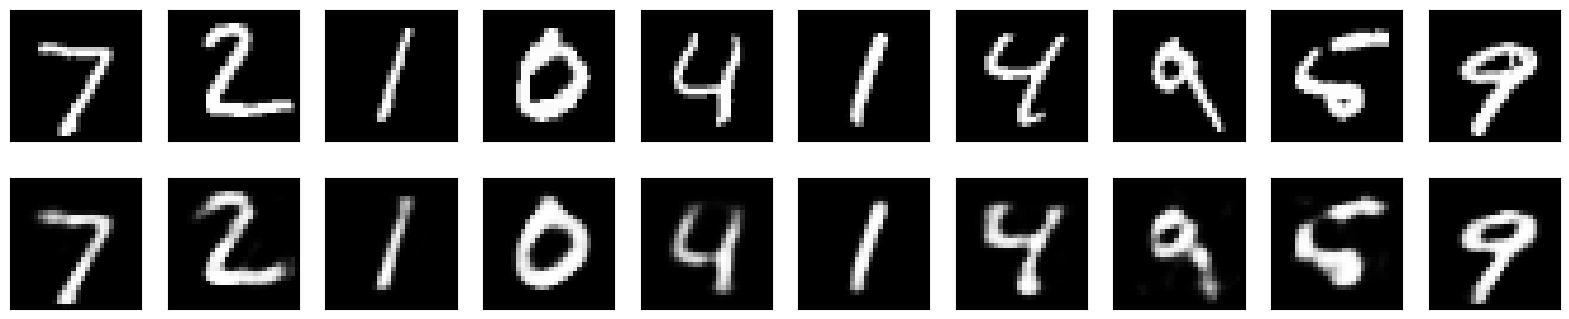

In [8]:
import matplotlib.pyplot as plt 

# Predict the test data 
reconstructed = autoencoder.predict(x_test) 

# Visualize the results 
n = 10  # Number of digits to display 
plt.figure(figsize=(20, 4)) 

for i in range(n): 
    # Display original 
    ax = plt.subplot(2, n, i + 1) 
    plt.imshow(x_test[i].reshape(28, 28)) 
    plt.gray() 
    ax.get_xaxis().set_visible(False) 
    ax.get_yaxis().set_visible(False) 

    # Display reconstruction 
    ax = plt.subplot(2, n, i + 1 + n) 
    plt.imshow(reconstructed[i].reshape(28, 28)) 
    plt.gray() 
    ax.get_xaxis().set_visible(False) 
    ax.get_yaxis().set_visible(False) 

plt.show()


In above output:<br>
- top row: original input images
- bottom row: reconstructed images produced by the autoencoder

So the model is not displaying two different evaluation outputs. It is showing a comparison:
original vs reconstruction.

 the second row can look “better” because the autoencoder often learns to keep the main digit shape
and drop small noise, blur, or stray pixels
so the reconstruction can look cleaner than the raw input

fine-tuning autoencoder:<br>
Fine-tuning the autoencoder by unfreezing some layers can help in improving its performance. Here I unfreeze the last four layers and train the model again for a few more epochs.

In [9]:
# Freeze all layers of the autoencoder
for layer in autoencoder.layers:
    layer.trainable = False


In [10]:
# Check trainable status of each layer
for i, layer in enumerate(autoencoder.layers):
    print(f"Layer {i}: {layer.name}, Trainable = {layer.trainable}")


Layer 0: input_layer, Trainable = False
Layer 1: dense, Trainable = False
Layer 2: dense_1, Trainable = False
Layer 3: dense_2, Trainable = False
Layer 4: dense_3, Trainable = False


In the below code I do:

1. Freeze all the Encoder Layers
2. Check the Status
3. Unfreeze the Encoder Layers
4. Compile and Train the Model

Recompile the model.


In [11]:
# Unfreeze the top layers of the encoder
for layer in autoencoder.layers[-4:]: 
    layer.trainable = True 

# Compile the model again
autoencoder.compile(optimizer='adam', loss='binary_crossentropy') 

# Train the model again
autoencoder.fit(x_train, x_train,  
                epochs=10,  
                batch_size=256,  
                shuffle=True,  
                validation_data=(x_test, x_test))


Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0935 - val_loss: 0.0922
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0932 - val_loss: 0.0923
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0931 - val_loss: 0.0920
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0929 - val_loss: 0.0917
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0928 - val_loss: 0.0917
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0926 - val_loss: 0.0915
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0925 - val_loss: 0.0912
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0923 - val_loss: 0.0913
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0922 - val_loss: 0.0910
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0921 - val_loss: 0.0911


denoising image

**1. Corrupt the input images with artificial noise:**
- Inject randomly generated noise into both the training set and the test set.
- Fit the autoencoder on these corrupted images as the inputs.
- Keep the clean, uncorrupted images as the desired outputs during training.

**2. Measure how well the model removes noise:**
- Run the noisy test images through the autoencoder to produce cleaned reconstructions.
- Visually compare three versions of each image: the noisy input, the reconstructed output, and the original clean image.

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1705 - val_loss: 0.1437
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1392 - val_loss: 0.1342
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1327 - val_loss: 0.1300
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.1294 - val_loss: 0.1278
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1275 - val_loss: 0.1265
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1263 - val_loss: 0.1255
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.1254 - val_loss: 0.1248
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.1248 - val_loss: 0.1245
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.1244 - val_loss: 0.1243
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.1241 - val_loss: 0.1238
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1236 - val_loss: 0.1232
Epoch 12/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 

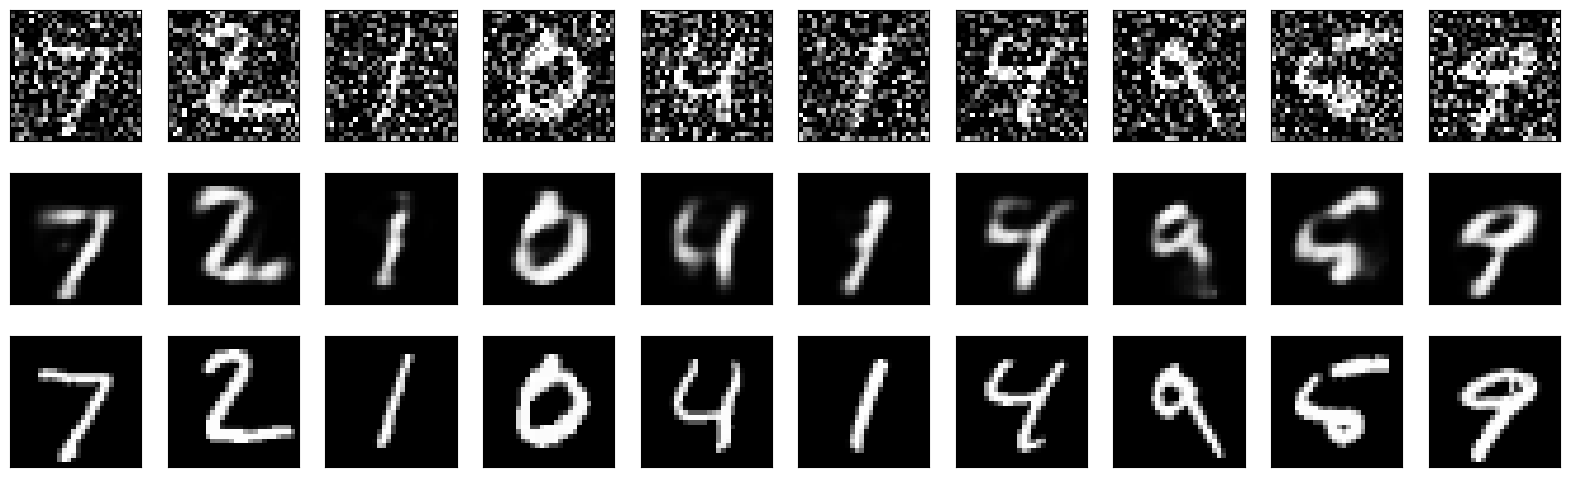

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Add noise to the data
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Train the autoencoder with noisy data
autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=512,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

# Denoise the test images
reconstructed_noisy = autoencoder.predict(x_test_noisy)

# Visualize the results
n = 10  # Number of digits to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    
    # Display denoised images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(reconstructed_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display original images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()
